# Sentinel-1 InSAR processing

This notebook provides an example to compute the geocoded InSAR coherence and the geocoded (flattened + terrain corrected + multilooked + filtered) interferogram on a user defined InSAR pair list

In [1]:
import openeo
from openeo.rest.stac_resource import StacResource
from openeo.internal.graph_building import PGNode

import rasterio
from rasterio.plot import show

import matplotlib.pyplot as plt

Create a datacube with the geocoded InSAR coherence and interferograms for a list of InSAR pairs

In [3]:
url = "https://openeo-staging.dataspace.copernicus.eu"
connection = openeo.connect(url).authenticate_oidc()

Authenticated using refresh token.


In [ ]:

# datacube = connection.datacube_from_process(
#     process_id="insar_interferogram_snaphu",
#     InSAR_pairs=[
#         ["2024-08-21", "2024-09-02"]
#     ],
#     burst_id=249435,
#     polarization="vv",
#     sub_swath="IW2",
#     coherence_window_rg=10,
#     coherence_window_az=2,
#     n_rg_looks=4,
#     n_az_looks=1,
# )
burst_id = 249435
polarization = "vv"
sub_swath = "IW2"
params = {
    "burst_id": burst_id,
    "polarization":  polarization,
    "sub_swath": sub_swath,
    "InSAR_pairs": [["2024-08-21", "2024-09-02"]],
    "coherence_window_rg":10,
    "coherence_window_az":2,
    "n_rg_looks":4,
    "n_az_looks":1
}

stac_resource = StacResource(
graph=PGNode(
    process_id="run_cwl_to_stac",
    arguments={
        "cwl_url": "https://raw.githubusercontent.com/cloudinsar/s1-workflows/refs/heads/keep_snap_metadata/cwl/sar_interferogram.cwl",
        "context": params,
    },
),
connection=connection,
)


merge_prefix = f"/interferogram/{burst_id}/{sub_swath}/20240821_20240902_custom_image"
stac_resource = stac_resource.export_workspace(
    "insar-results-workspace",
    merge=merge_prefix,
    )
job = stac_resource.create_job(title=merge_prefix,job_options={"python-memory": "4000m"})
# datacube = stac_resource.save_result(format='GTiff')

In [13]:
job.start_job()
# job.get_results().download_files()

<BatchJob job_id='j-26010908063744829b1780d1b5031004'>

In [7]:
job = connection.job("j-26020915190041ea8a815c8c90268d92")
job

<BatchJob job_id='j-26020915190041ea8a815c8c90268d92'>

In [8]:
bucket_prefix = "https://s3.waw4-1.cloudferro.com/insar-results-waw4-1-og7jvye2c848fi4ug1bvvrp21n298y29khmcvm6hbt"
merge_prefix = job.describe()["process"]["process_graph"]["exportworkspace1"]["arguments"]["merge"]

stac_url = bucket_prefix + merge_prefix + "/collection.json"
stac_url

'https://s3.waw4-1.cloudferro.com/insar-results-waw4-1-og7jvye2c848fi4ug1bvvrp21n298y29khmcvm6hbt/interferogram/249435/IW2/20240821_20240902_custom_image/collection.json'

In [16]:
import pystac

coll = pystac.read_file(stac_url)
coll

<Collection id=unknown-job>

In [22]:
for l in coll.links:
    print(l.href)

./collection.json
https://s3.waw4-1.cloudferro.com/insar-results-waw4-1-og7jvye2c848fi4ug1bvvrp21n298y29khmcvm6hbt/interferogram/249435/IW2/20240821_20240902_custom_image/collection.json
./phase_coh_20240821T170739_20240902T170739.tif.json


Download link is composed by bucket prefix + file:

bucket prefix: `https://s3.waw4-1.cloudferro.com/insar-results-waw4-1-og7jvye2c848fi4ug1bvvrp21n298y29khmcvm6hbt/
merge_prefix: `interferogram/249435/IW2/20240821_20240902_custom_image/`
result file: `phase_coh_20240821T170739_20240902T170739.tif`

In [23]:
!wget https://s3.waw4-1.cloudferro.com/insar-results-waw4-1-og7jvye2c848fi4ug1bvvrp21n298y29khmcvm6hbt/interferogram/249435/IW2/20240821_20240902_custom_image/phase_coh_20240821T170739_20240902T170739.tif

--2026-03-03 09:23:24--  https://s3.waw4-1.cloudferro.com/insar-results-waw4-1-og7jvye2c848fi4ug1bvvrp21n298y29khmcvm6hbt/interferogram/249435/IW2/20240821_20240902_custom_image/phase_coh_20240821T170739_20240902T170739.tif
Resolving s3.waw4-1.cloudferro.com (s3.waw4-1.cloudferro.com)... 194.146.52.75
Connecting to s3.waw4-1.cloudferro.com (s3.waw4-1.cloudferro.com)|194.146.52.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 96500326 (92M) [binary/octet-stream]
Saving to: ‘phase_coh_20240821T170739_20240902T170739.tif’

phase_coh_20240821T 100%[===================>]  92.03M  83.3MB/s    in 1.1s    

2026-03-03 09:23:25 (83.3 MB/s) - ‘phase_coh_20240821T170739_20240902T170739.tif’ saved [96500326/96500326]



# Visualization of the results

Visualize the band names

In [24]:
with rasterio.open('phase_coh_20240821T170739_20240902T170739.tif') as src:
    print(src.descriptions)

('Phase_ifg_VV', 'Unw_Phase_ifg_VV', 'coh_VV')


Visualize the interferogram

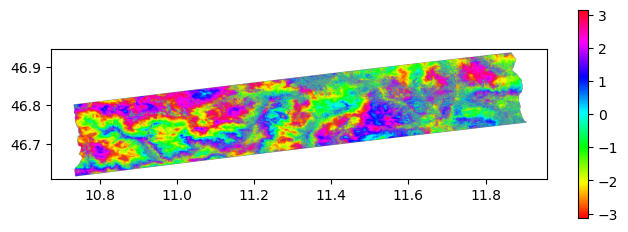

In [25]:
with rasterio.open('phase_coh_20240821T170739_20240902T170739.tif') as src:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = show(src.read(1), transform=src.transform, cmap='hsv', ax=ax)
    cbar = fig.colorbar(im.get_images()[0], ax=ax, orientation="vertical", shrink=0.45)

Visualize the unwrapped interferogram

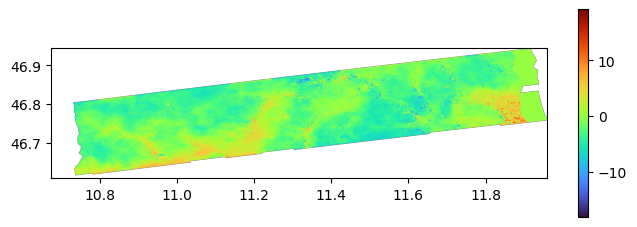

In [26]:
with rasterio.open('phase_coh_20240821T170739_20240902T170739.tif') as src:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = show(src.read(2), transform=src.transform, cmap='turbo', ax=ax)
    cbar = fig.colorbar(im.get_images()[0], ax=ax, orientation="vertical", shrink=0.45)

Visualize the InSAR coherence

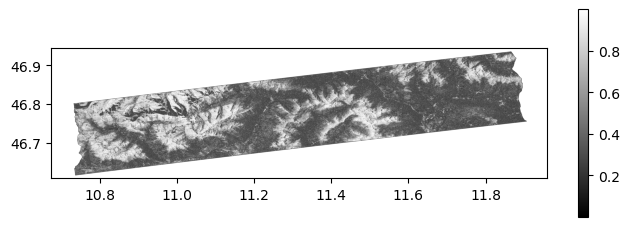

In [27]:
with rasterio.open('phase_coh_20240821T170739_20240902T170739.tif') as src:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = show(src.read(3), transform=src.transform, cmap='gray', ax=ax)
    cbar = fig.colorbar(im.get_images()[0], ax=ax, orientation="vertical", shrink=0.45)